# Flight Delay and Cancellation Analysis (Part 1)

This notebook contains one consolidated and functional Part 1 workflow.
It merges the previous organized narrative with the currently working implementation.

## Notebook Goals

- Build a reliable preprocessing and feature-engineering pipeline.
- Perform exploratory analysis and dimensionality reduction.
- Run hypothesis testing to statistically validate feature relevance.
- Save intermediate and final checkpoints for reproducibility.

## Execution Phases

1. Problem formulation
2. Data loading and cleansing
3. Feature engineering and transformation
4. EDA and dimensionality reduction
5. Hypothesis testing and artifact export

> Tip: set `NROWS = 10000` for a quick run, or `NROWS = None` for the full dataset.


In [73]:
from pathlib import Path
import sys

import pandas as pd

# Resolve project root dynamically to avoid hardcoded absolute paths.
project_root = Path.cwd().resolve()
while project_root != project_root.parent and project_root.name != "DataScience_IA":
    project_root = project_root.parent

if project_root.name != "DataScience_IA":
    raise FileNotFoundError("Could not locate project root folder 'DataScience_IA'.")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Project_Code.PythonCode.DataPreProcessor.FlightDataCleaner import FlightDataCleaner
from Project_Code.PythonCode.FeatureEngeneering.FlightFeatureEngineer import FlightFeatureEngineer
from Project_Code.PythonCode.EDA.FlightEDA import FlightEDA
from Project_Code.PythonCode.Util.DataVisualization import DataVisualization
from Project_Code.PythonCode.Util.DataLoader import DataLoader
from Project_Code.PythonCode.HypothesisTesting.HypothesisTester import HypothesisTester


dataset_path = project_root / "DataSet" / "flights_sample_3m.csv"
output_dir = project_root / "Output_Files"
output_dir.mkdir(parents=True, exist_ok=True)

# DataLoader now auto-downloads the dataset if this local CSV is missing.
# Keep dataset_path as the target location where the CSV should exist/be created.

# Runtime configuration.
NROWS = 10000
TEST_SIZE = 0.2
RANDOM_STATE = 42

print("Project root:", project_root)
print("Dataset path:", dataset_path)
print("Output dir:", output_dir)


Project root: C:\Users\Lenovo\Desktop\DataScience_IA
Dataset path: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\flights_sample_3m.csv
Output dir: C:\Users\Lenovo\Desktop\DataScience_IA\Output_Files


## Phase 1 - Problem Formulation

This project studies domestic US flight operations (2019-2023) with two predictive targets and one exploratory objective.

### Main Analytical Objectives

1. **Regression task**: predict `ARR_DELAY` (arrival delay in minutes).
2. **Classification task**: predict `DELAY_CLASS` after feature engineering.
3. **Exploratory objective**: identify operational patterns and group-level behavior.

### Leakage-Aware Perspective

A key requirement is to avoid data leakage by excluding post-departure and post-arrival signals during modeling preparation.
This ensures that engineered features represent information realistically available before departure.


In [74]:
phase1_summary = pd.DataFrame(
    {
        "Objective": ["Regression", "Classification", "Pattern Discovery"],
        "Target / Focus": ["ARR_DELAY", "DELAY_CLASS", "EDA + Reduction"],
    }
)
phase1_summary


,Objective,Target / Focus
0,Regression,ARR_DELAY
1,Classification,DELAY_CLASS
2,Pattern Discovery,EDA + Reduction


## Phase 2 - Data Loading and Cleansing

This phase standardizes the raw data preparation pipeline and persists an intermediate checkpoint.

### Steps

1. Load raw data from CSV.
2. Clean raw records (cancelled/diverted filtering, leakage column removal, outlier treatment, null handling).
3. Split cleaned data into train/test sets.
4. Validate resulting cleaned dataset dimensions and quality.


In [75]:
# STEP 1: Load raw data
print("Loading raw dataset...")
loader = DataLoader(str(dataset_path), test_size=TEST_SIZE, random_state=RANDOM_STATE)
df_raw = pd.read_csv(dataset_path, nrows=NROWS)
print(f"Raw data loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")


Loading raw dataset...
Raw data loaded: 10000 rows × 32 columns


In [76]:
# STEP 2: Clean the dataset
cleaner = FlightDataCleaner(df=df_raw)
df_clean = cleaner.load_and_clean(nrows=None, random_state=RANDOM_STATE)
df_clean.to_csv("../../DataSet/cleaned_flight_data.csv", index=False)

df_clean["DELAY_CLASS"] = df_clean["ARR_DELAY"].apply(
    lambda x: "on_time" if x < 15 else ("short_delay" if x <= 30 else "long_delay")
)

print("Clean shape:", df_clean.shape)
print("Numeric missing values after cleaning:", int(df_clean.select_dtypes(include=["number"]).isnull().sum().sum()))
df_clean.head(3)


INICIANDO PROCESSO DE LIMPEZA DE DADOS

1. A usar DataFrame fornecido no construtor...
   ✓ Dataset carregado: 10000 linhas × 32 colunas

2. A remover voos cancelados e desviados...
   ✓ Removidos 270 voos (cancelados/desviados)

3. A remover colunas com data leakage...
   ✓ Removidas 17 colunas com data leakage

4. A remover nulos na variável alvo...
   ✓ Removidas 0 linhas com ARR_DELAY nulo

5. A converter atrasos negativos para zero...
   ✓ 6324 valores negativos de ARR_DELAY convertidos para 0

6. A balancear dataset (atrasos positivos vs zeros)...
   ✓ Dataset balanceado: 3212 atrasos positivos + 3212 zeros

7. A tratar outliers e missing values...
   ✓ DISTANCE: 359 outliers tratados
   ✓ CRS_ELAPSED_TIME: 307 outliers tratados
   ✓ Nenhum missing value encontrado

8. A remover colunas redundantes...
   ✓ Removidas 5 colunas redundantes

LIMPEZA CONCLUÍDA!
Dimensão final: 6424 linhas × 10 colunas
Redução: 3576 linhas removidas (35.8%)

Clean shape: (6424, 11)
Numeric missing val

,FL_DATE,AIRLINE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE,DELAY_CLASS
0,2021-01-09,SkyWest Airlines Inc.,OO,DEN,SUN,1150,1354,11.0,124.0,557.0,on_time
1,2020-02-23,United Air Lines Inc.,UA,MFE,IAH,720,835,0.0,75.0,316.0,on_time
2,2019-02-19,Southwest Airlines Co.,WN,ABQ,SAN,630,730,0.0,120.0,628.0,on_time


In [77]:
# STEP 3: Split cleaned data into train/test sets
loader.data = df_clean
data_train, data_test, target_train, target_test = loader.split_data(target_column='ARR_DELAY')

print("Train shape:", data_train.shape)
print("Test shape:", data_test.shape)
print("Target train shape:", target_train.shape if target_train is not None else None)
print("Target test shape:", target_test.shape if target_test is not None else None)



Data split completed: 5139 train × 1285 test
Train shape: (5139, 10)
Test shape: (1285, 10)
Target train shape: (5139,)
Target test shape: (1285,)


## Phase 4 - Exploratory Data Analysis and Dimensionality Reduction

This section combines analytical diagnostics with visual diagnostics.

### Analytical diagnostics

- Distribution and descriptive summaries
- Variable ranges and correlation structure
- Data quality checks

### Dimensionality reduction

- PCA for linear structure
- UMAP (or t-SNE fallback) for non-linear structure


INICIANDO ANALISE EXPLORATORIA (EDA)
INICIANDO EDA ANALITICA

ESTATISTICAS DESCRITIVAS
Resumo geral:
       CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME     DISTANCE    ARR_DELAY
count   6424.000000   6424.000000       6424.000000  6424.000000  6424.000000
mean    1342.808531   1502.213730        132.775053   717.698599    19.316936
std      484.618361    516.789233         53.282328   417.425159    55.174007
min        7.000000      1.000000         33.000000    61.000000     0.000000
25%      930.000000   1117.000000         91.000000   391.750000     0.000000
50%     1336.000000   1534.000000        126.000000   668.000000     0.500000
75%     1735.000000   1927.000000        164.000000   966.000000    17.000000
max     2359.000000   2359.000000        301.000000  2016.000000  1185.000000

Resumo por grupo (DELAY_CLASS):
            CRS_DEP_TIME                                                  \
                   count         mean         std   min      25%     50%   
DELAY_CLASS 

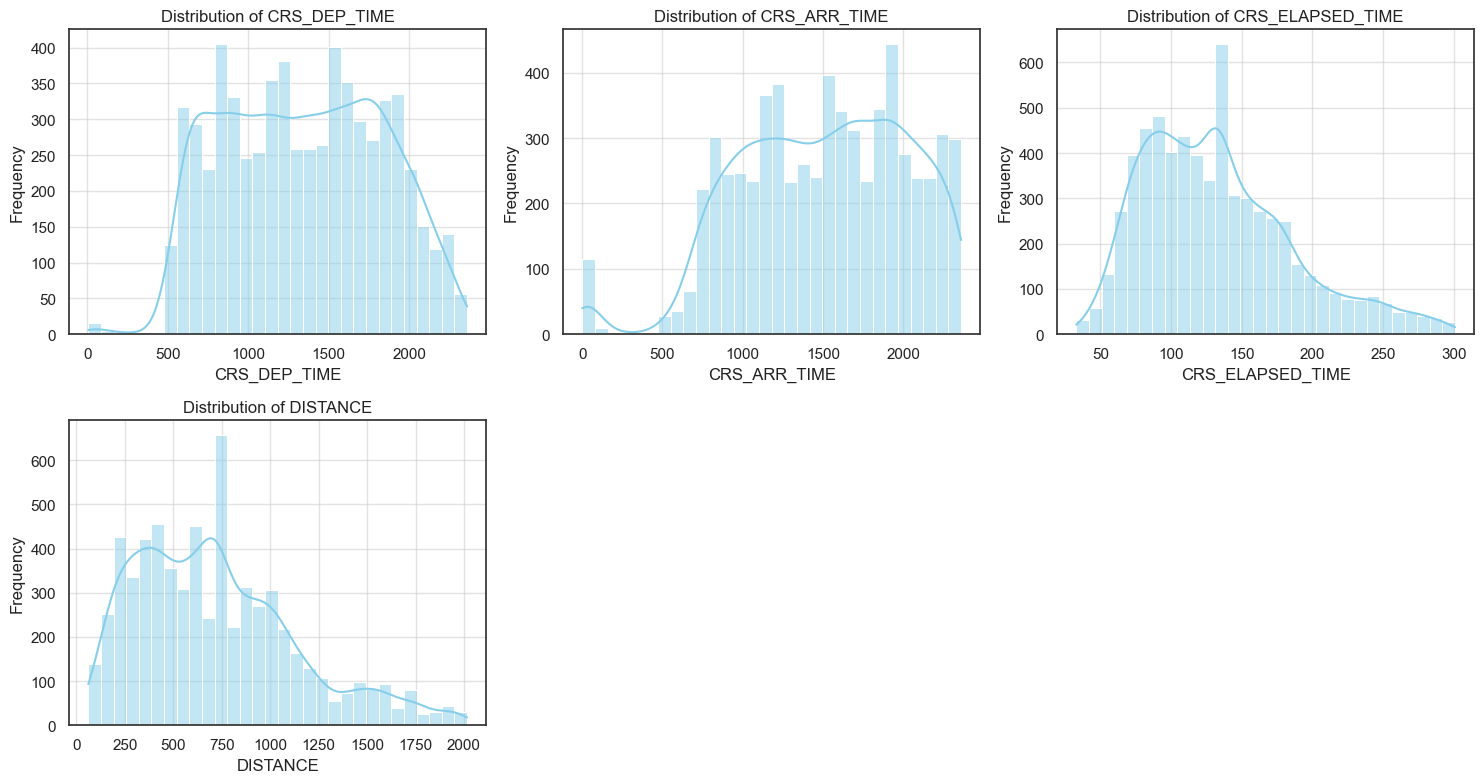

[OK] Histograms saved: eda_distributions.png
Generating correlation matrix...


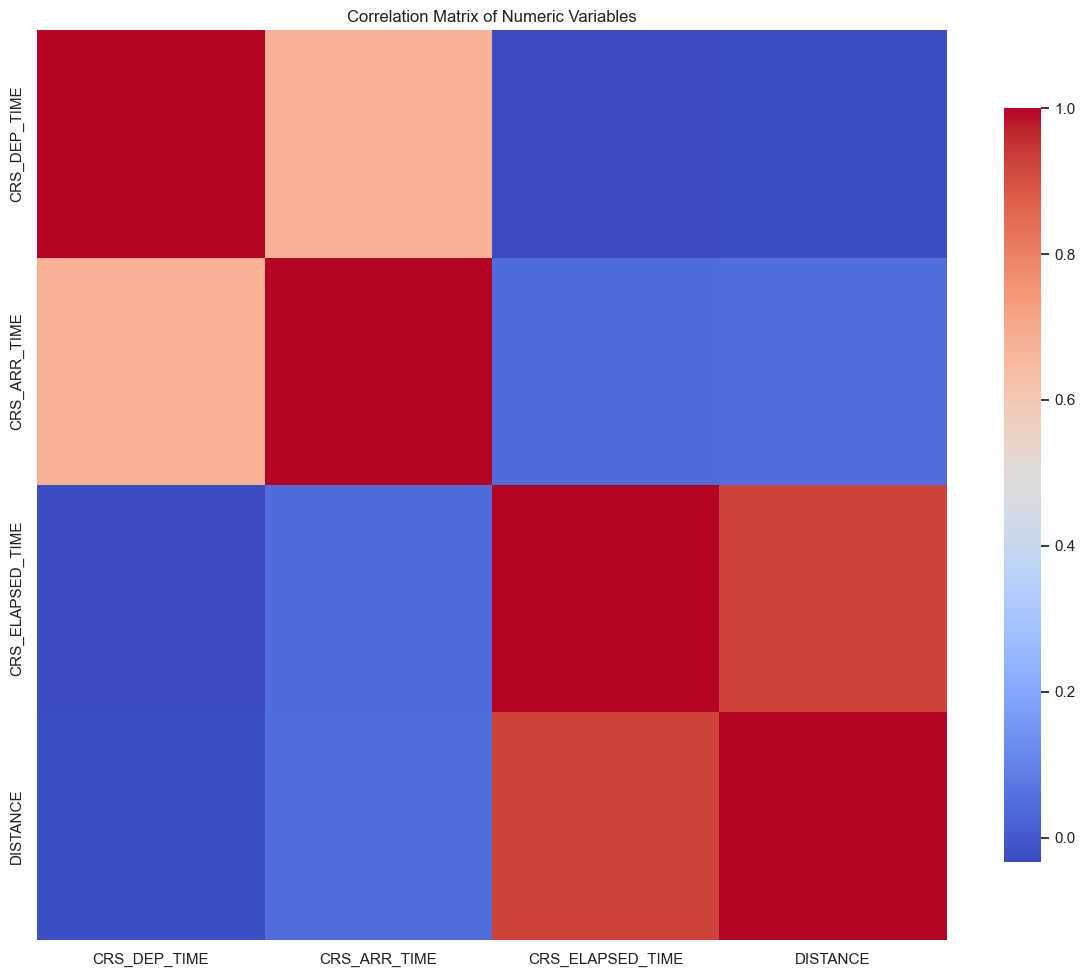

[OK] Correlation matrix saved: eda_correlation_matrix.png
Generating boxplots for 4 columns...


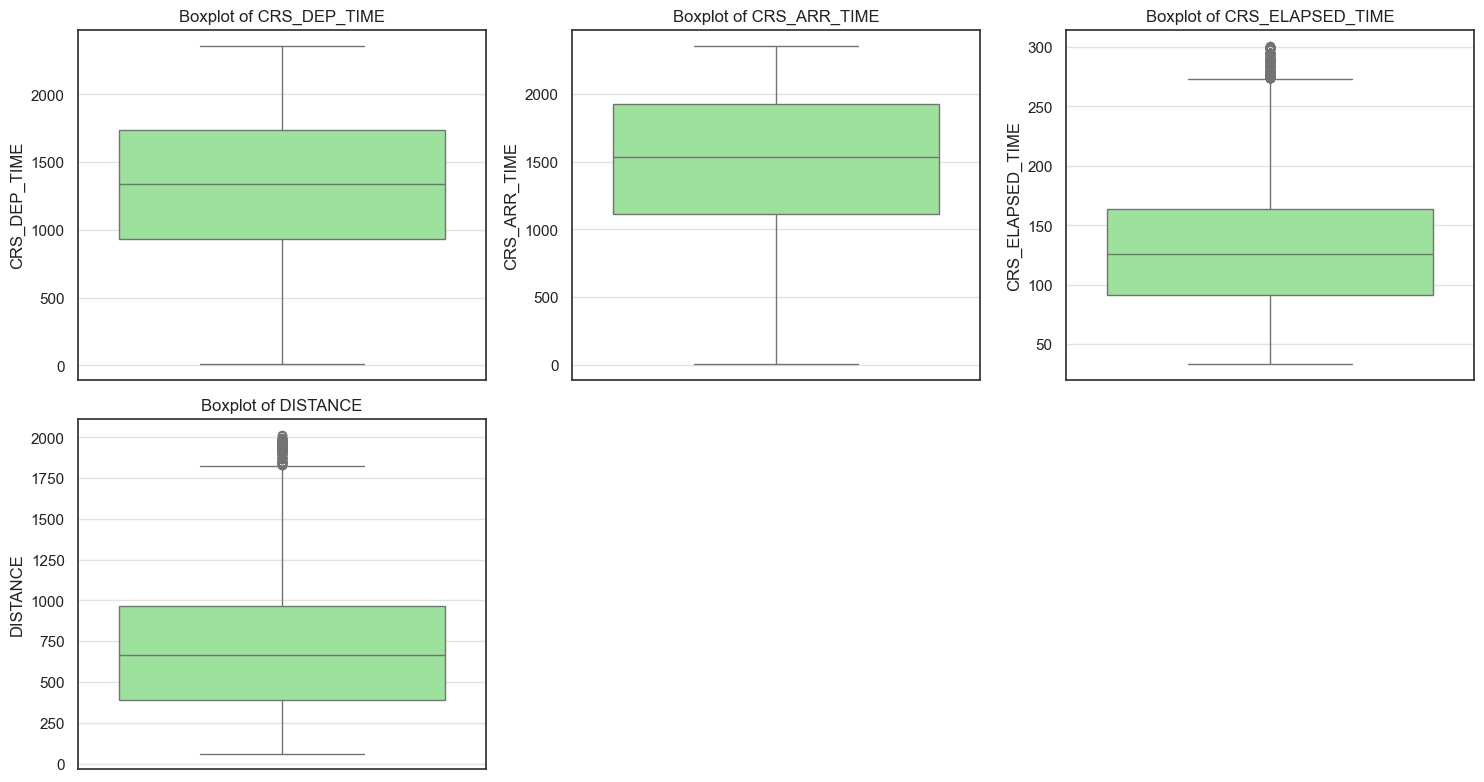

[OK] Boxplots saved: eda_boxplots.png

4. Generating target variable distribution...


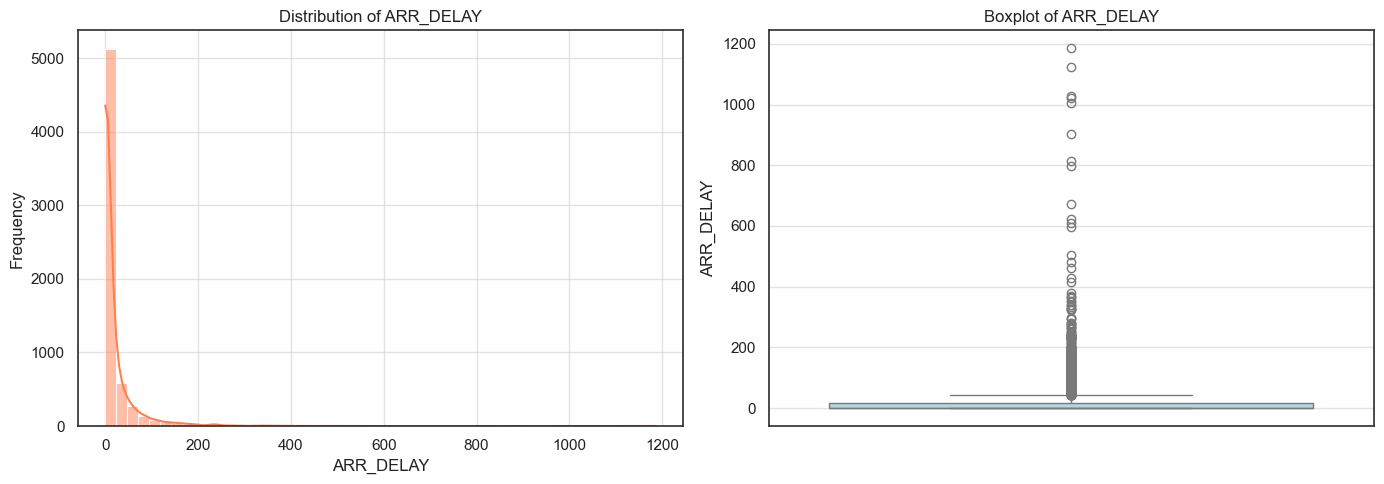

[OK] Target distribution saved: eda_target_distribution.png
EDA VISUAL (GRAFICOS BASE) CONCLUIDA!

INICIANDO EDA VISUAL AGRUPADA (DELAY_CLASS)
Generating grouped histograms for 4 columns...


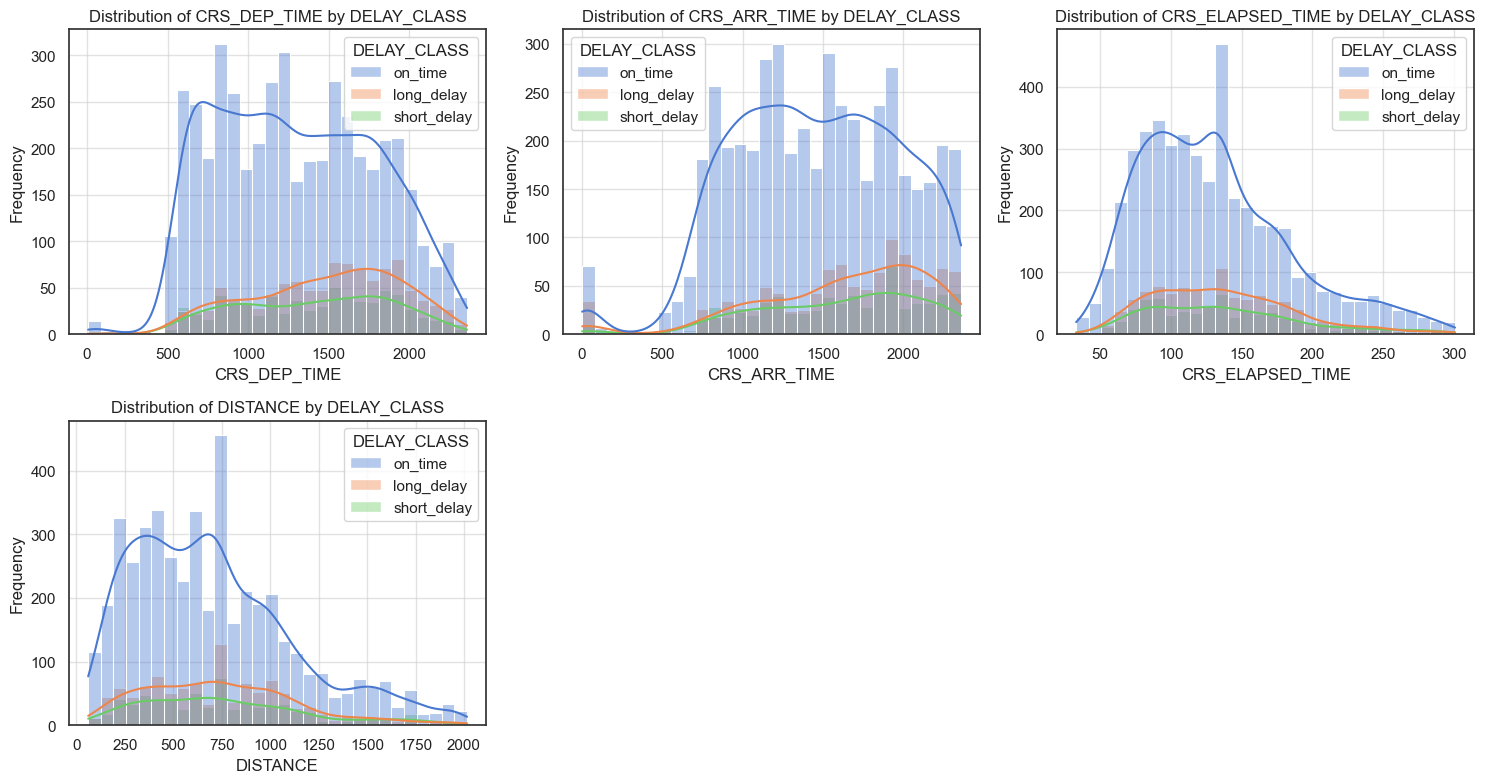

[OK] Grouped histograms saved: eda_grouped_distributions.png
Generating grouped boxplots for 4 columns...


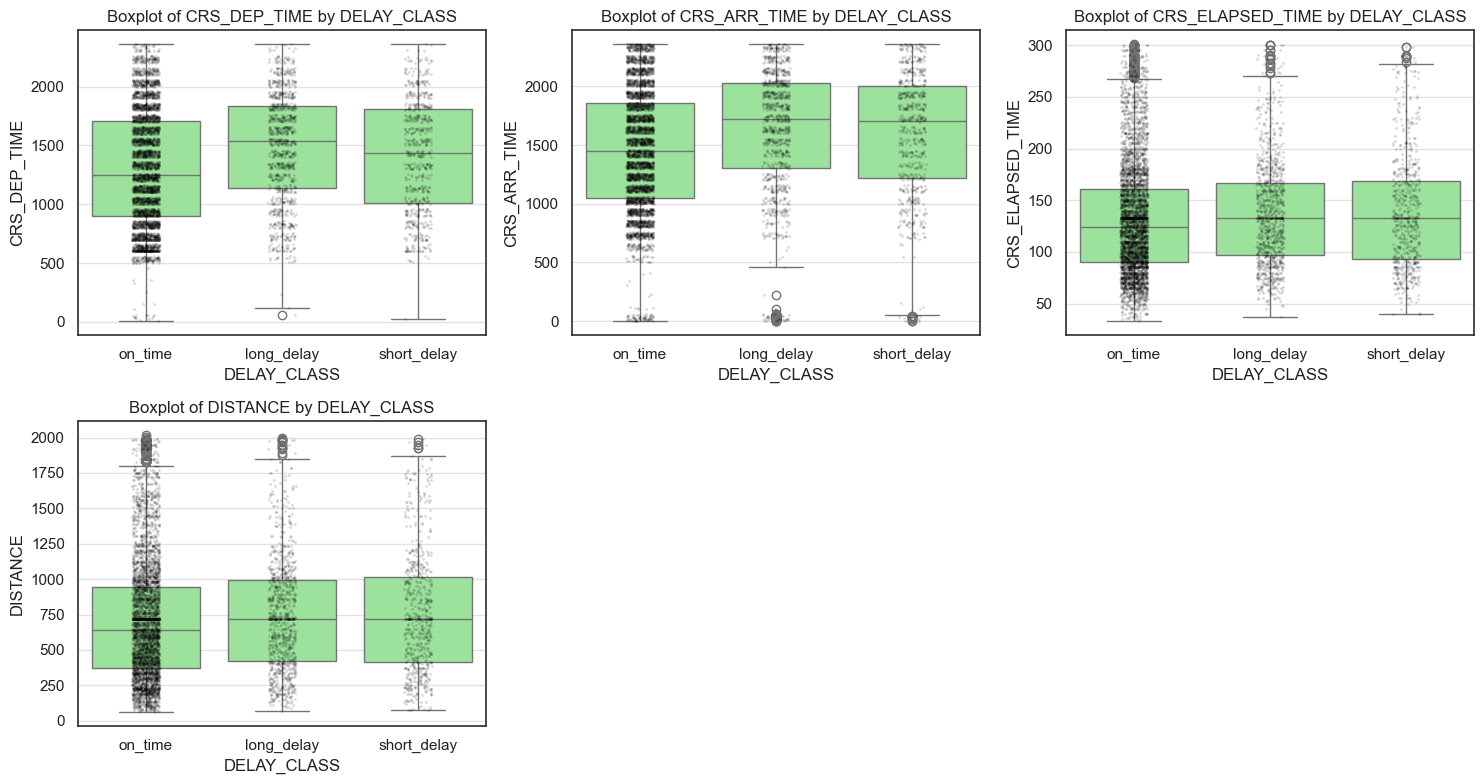

[OK] Grouped boxplots saved: eda_grouped_boxplots.png
EDA VISUAL AGRUPADA CONCLUIDA!

EDA CONCLUIDA!

Missing values total: 0
Duplicate rows: 0
Top outlier counts:
ARR_DELAY           799
CRS_ELAPSED_TIME    111
DISTANCE             98
CRS_DEP_TIME          0
CRS_ARR_TIME          0
dtype: int64


In [78]:
# STEP 7: Run full EDA routine
eda = FlightEDA(df_clean, target_col="ARR_DELAY", output_dir=output_dir, group_col="DELAY_CLASS")
eda_report = eda.perform_eda()

print("Missing values total:", int(eda_report["quality"]["missing_values"].sum()))
print("Duplicate rows:", int(eda_report["quality"]["duplicate_count"]))
print("Top outlier counts:")
print(eda_report["quality"]["outlier_count"].head(5))


In [79]:
# STEP 8: PCA
pca_components = eda.run_pca(n_components=2, explained_variance_threshold=0.8)

print("PCA type:", type(pca_components))
print("PCA shape:", pca_components.shape)



EXECUTANDO PCA (Análise de Componentes Principais)

Componentes PCA necessários para 80.0% variância: 2
Variância explicada (primeiros 2 componentes):
  PC1: 48.27%
  PC2: 41.87%

✓ PCA executado e visualizado: eda_pca_2d.png

PCA type: <class 'numpy.ndarray'>
PCA shape: (6424, 2)


### Detailed Analytical EDA Outputs

The following cells expose explicit analytical components from the EDA class.
These are useful when building a written report because each diagnostic can be cited independently.


In [80]:
eda.describe_variables()



ESTATISTICAS DESCRITIVAS
Resumo geral:
       CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME     DISTANCE    ARR_DELAY
count   6424.000000   6424.000000       6424.000000  6424.000000  6424.000000
mean    1342.808531   1502.213730        132.775053   717.698599    19.316936
std      484.618361    516.789233         53.282328   417.425159    55.174007
min        7.000000      1.000000         33.000000    61.000000     0.000000
25%      930.000000   1117.000000         91.000000   391.750000     0.000000
50%     1336.000000   1534.000000        126.000000   668.000000     0.500000
75%     1735.000000   1927.000000        164.000000   966.000000    17.000000
max     2359.000000   2359.000000        301.000000  2016.000000  1185.000000

Resumo por grupo (DELAY_CLASS):
            CRS_DEP_TIME                                                  \
                   count         mean         std   min      25%     50%   
DELAY_CLASS                                                              

{'overall':        CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME     DISTANCE    ARR_DELAY
 count   6424.000000   6424.000000       6424.000000  6424.000000  6424.000000
 mean    1342.808531   1502.213730        132.775053   717.698599    19.316936
 std      484.618361    516.789233         53.282328   417.425159    55.174007
 min        7.000000      1.000000         33.000000    61.000000     0.000000
 25%      930.000000   1117.000000         91.000000   391.750000     0.000000
 50%     1336.000000   1534.000000        126.000000   668.000000     0.500000
 75%     1735.000000   1927.000000        164.000000   966.000000    17.000000
 max     2359.000000   2359.000000        301.000000  2016.000000  1185.000000,
 'by_group':             CRS_DEP_TIME                                                  \
                    count         mean         std   min      25%     50%   
 DELAY_CLASS                                                                
 long_delay        1078.0  1482.51

In [81]:
eda.determine_range()



AMPLITUDE DAS VARIAVEIS
Amplitude geral:
CRS_DEP_TIME        2352.0
CRS_ARR_TIME        2358.0
CRS_ELAPSED_TIME     268.0
DISTANCE            1955.0
ARR_DELAY           1185.0
dtype: float64

Amplitude por grupo (DELAY_CLASS):
             CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  DISTANCE  ARR_DELAY
DELAY_CLASS                                                                   
long_delay           2300          2357             263.0    1926.0     1154.0
on_time              2352          2357             268.0    1955.0       14.0
short_delay          2334          2358             258.0    1917.0       15.0



{'overall': CRS_DEP_TIME        2352.0
 CRS_ARR_TIME        2358.0
 CRS_ELAPSED_TIME     268.0
 DISTANCE            1955.0
 ARR_DELAY           1185.0
 dtype: float64,
 'by_group':              CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  DISTANCE  ARR_DELAY
 DELAY_CLASS                                                                   
 long_delay           2300          2357             263.0    1926.0     1154.0
 on_time              2352          2357             268.0    1955.0       14.0
 short_delay          2334          2358             258.0    1917.0       15.0}

In [82]:
eda.assess_correlation()



CORRELACAO ENTRE VARIAVEIS
Correlacao geral:
                  CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  DISTANCE  \
CRS_DEP_TIME          1.000000      0.675575         -0.033131 -0.024896   
CRS_ARR_TIME          0.675575      1.000000          0.039943  0.044312   
CRS_ELAPSED_TIME     -0.033131      0.039943          1.000000  0.927078   
DISTANCE             -0.024896      0.044312          0.927078  1.000000   
ARR_DELAY             0.087475      0.081677          0.015275  0.012594   

                  ARR_DELAY  
CRS_DEP_TIME       0.087475  
CRS_ARR_TIME       0.081677  
CRS_ELAPSED_TIME   0.015275  
DISTANCE           0.012594  
ARR_DELAY          1.000000  

Correlacao por grupo (DELAY_CLASS):

[long_delay]
                  CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  DISTANCE  \
CRS_DEP_TIME          1.000000      0.535781         -0.050676 -0.041671   
CRS_ARR_TIME          0.535781      1.000000          0.022431  0.039000   
CRS_ELAPSED_TIME     -0.050676      0.

{'overall':                   CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  DISTANCE  \
 CRS_DEP_TIME          1.000000      0.675575         -0.033131 -0.024896   
 CRS_ARR_TIME          0.675575      1.000000          0.039943  0.044312   
 CRS_ELAPSED_TIME     -0.033131      0.039943          1.000000  0.927078   
 DISTANCE             -0.024896      0.044312          0.927078  1.000000   
 ARR_DELAY             0.087475      0.081677          0.015275  0.012594   
 
                   ARR_DELAY  
 CRS_DEP_TIME       0.087475  
 CRS_ARR_TIME       0.081677  
 CRS_ELAPSED_TIME   0.015275  
 DISTANCE           0.012594  
 ARR_DELAY          1.000000  ,
 'by_group': {'long_delay':                   CRS_DEP_TIME  CRS_ARR_TIME  CRS_ELAPSED_TIME  DISTANCE  \
  CRS_DEP_TIME          1.000000      0.535781         -0.050676 -0.041671   
  CRS_ARR_TIME          0.535781      1.000000          0.022431  0.039000   
  CRS_ELAPSED_TIME     -0.050676      0.022431          1.000000  0.916383   


In [83]:
eda.assess_quality()



QUALIDADE DO DATASET
Missing values por coluna:
CRS_DEP_TIME        0
CRS_ARR_TIME        0
CRS_ELAPSED_TIME    0
DISTANCE            0
ARR_DELAY           0
dtype: int64

Duplicados no dataframe: 0

Outliers por coluna (IQR):
ARR_DELAY           799
CRS_ELAPSED_TIME    111
DISTANCE             98
CRS_DEP_TIME          0
CRS_ARR_TIME          0
dtype: int64



{'missing_values': CRS_DEP_TIME        0
 CRS_ARR_TIME        0
 CRS_ELAPSED_TIME    0
 DISTANCE            0
 ARR_DELAY           0
 dtype: int64,
 'duplicate_count': 0,
 'outlier_count': ARR_DELAY           799
 CRS_ELAPSED_TIME    111
 DISTANCE             98
 CRS_DEP_TIME          0
 CRS_ARR_TIME          0
 dtype: int64}

### Visual EDA Outputs

These cells generate key plots used for interpretation and documentation.
All figures are written to `Output_Files`.


Generating histograms for 4 columns...


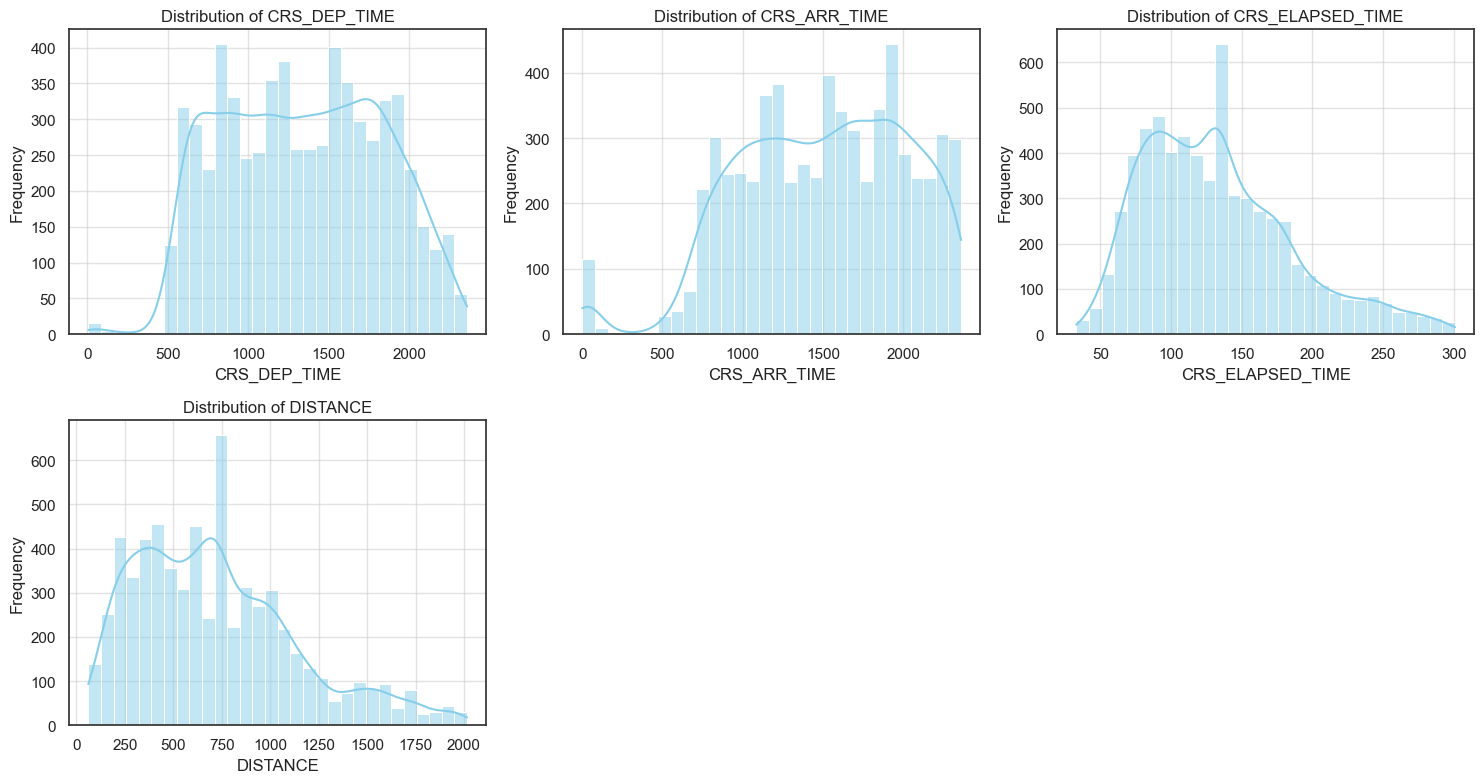

[OK] Histograms saved: eda_distributions.png


In [84]:
eda.viz.plot_distributions()


Generating correlation matrix...


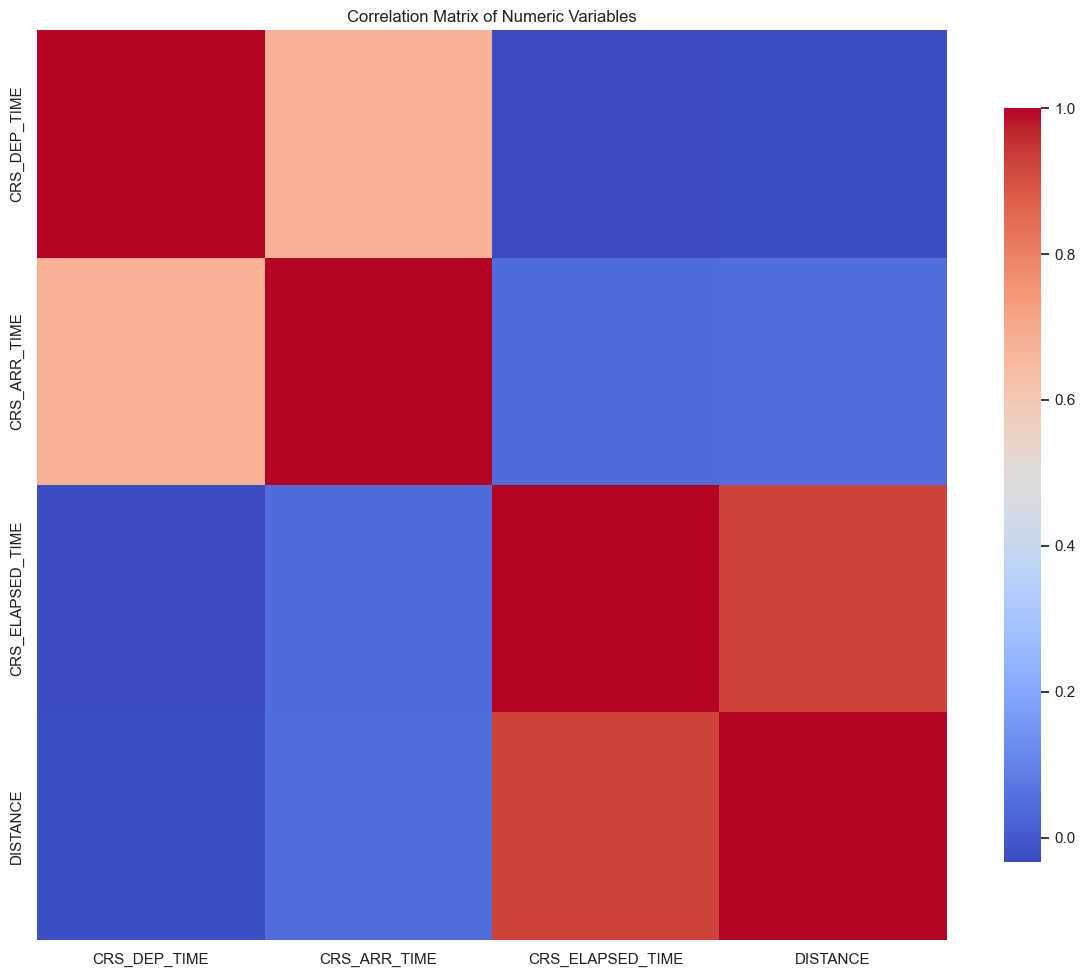

[OK] Correlation matrix saved: eda_correlation_matrix.png


In [85]:
eda.viz.plot_correlation_matrix(filename="eda_correlation_matrix.png")


Generating boxplots for 4 columns...


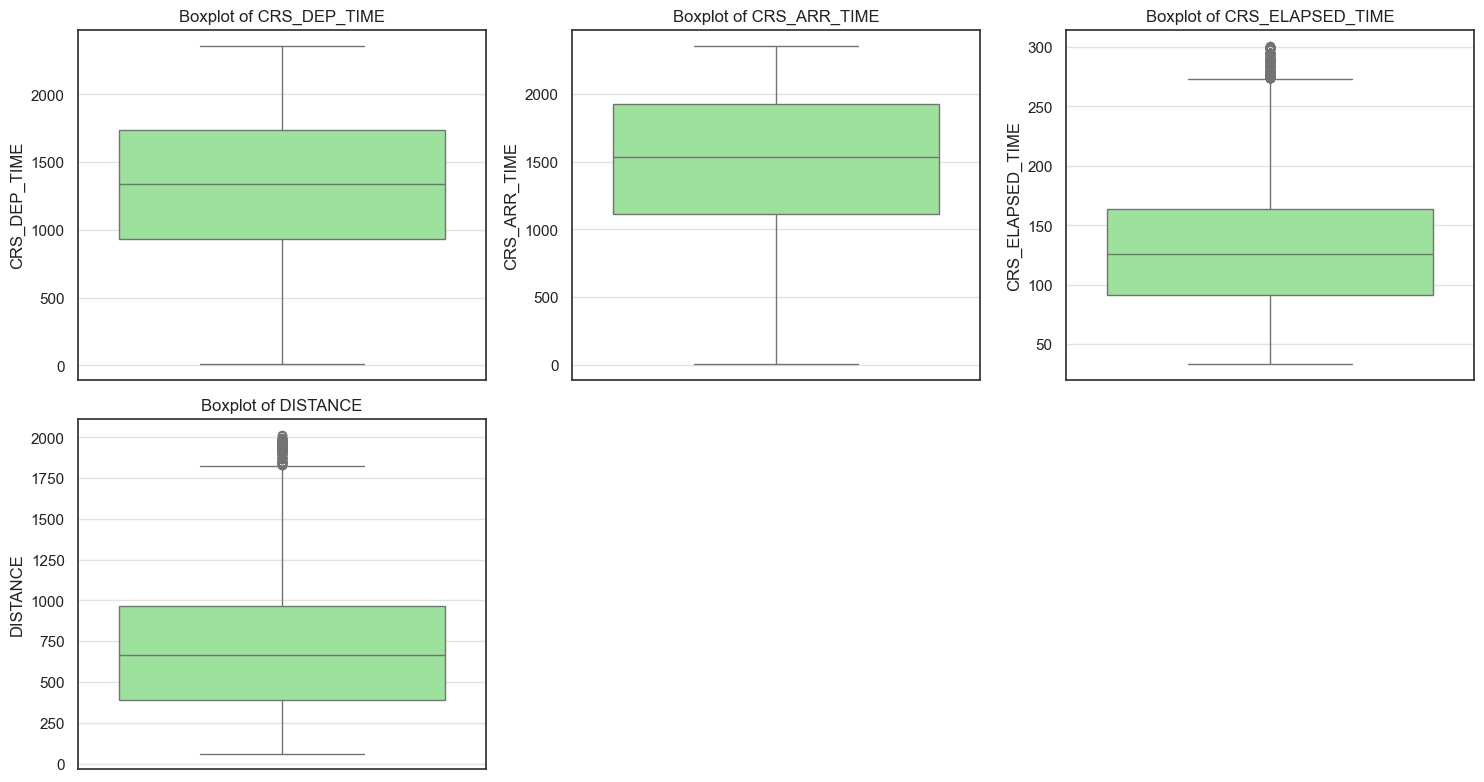

[OK] Boxplots saved: eda_boxplots.png


In [86]:
eda.viz.plot_boxplots(columns=eda.numeric_cols, filename="eda_boxplots.png")



4. Generating target variable distribution...


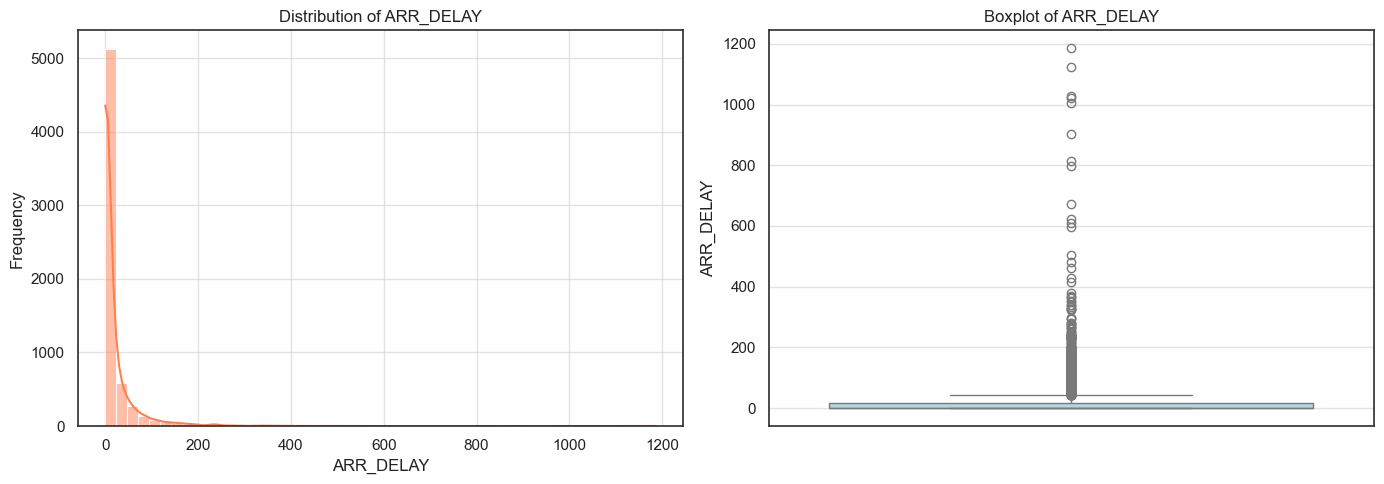

[OK] Target distribution saved: eda_target_distribution.png


In [87]:
eda.viz.plot_target_distribution(filename="eda_target_distribution.png")



EXECUTANDO UMAP (Análise de Dimensionalidade Não-Linear)

Aplicando UMAP...


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


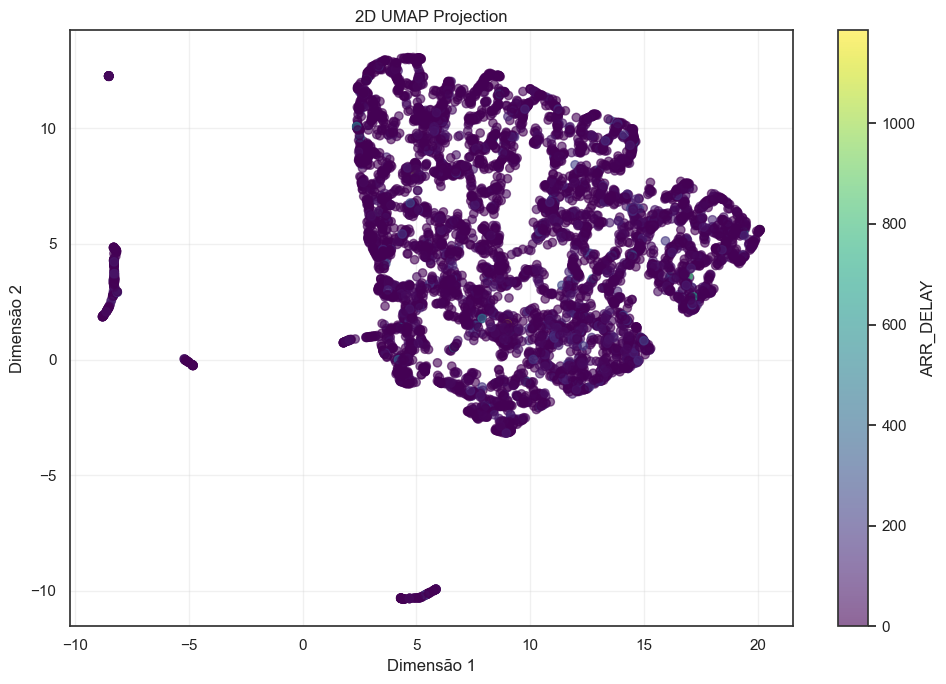


✓ UMAP executado e visualizado: eda_umap_2d.png

UMAP/t-SNE type: <class 'numpy.ndarray'>
UMAP/t-SNE shape: (6424, 2)


In [88]:
# STEP 9: UMAP/t-SNE
umap_components = eda.run_umap_or_tsne(n_components=2, use_umap=True)

print("UMAP/t-SNE type:", type(umap_components))
print("UMAP/t-SNE shape:", umap_components.shape)


Generating top 20 correlations heatmap...


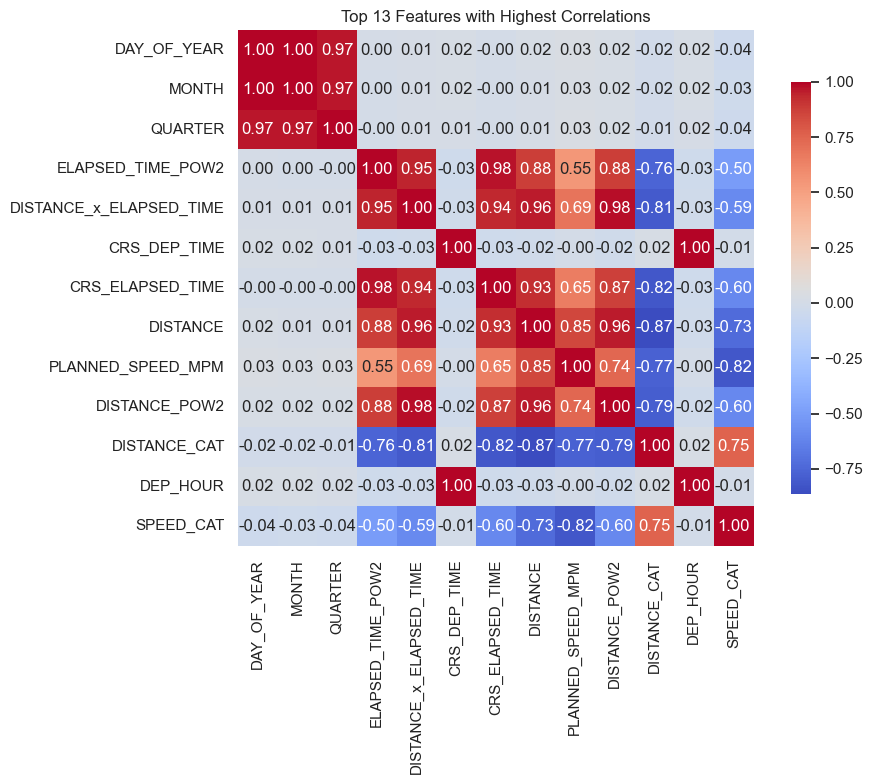

[OK] Heatmap saved: viz_heatmap_top_correlations.png
Generating grouped histograms for 4 columns...


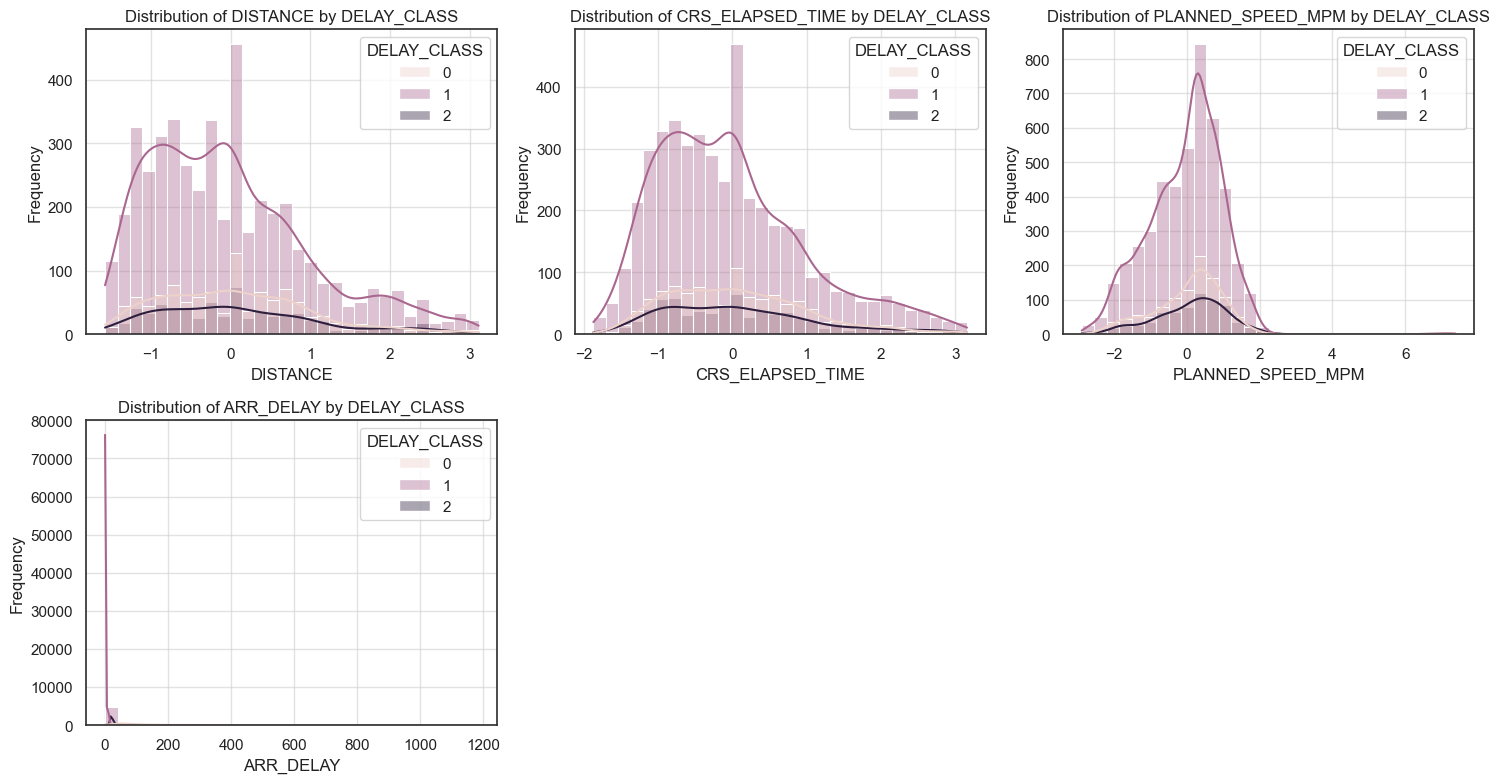

[OK] Grouped histograms saved: viz_grouped_distributions_delay_class.png
Generating grouped boxplots for 4 columns...


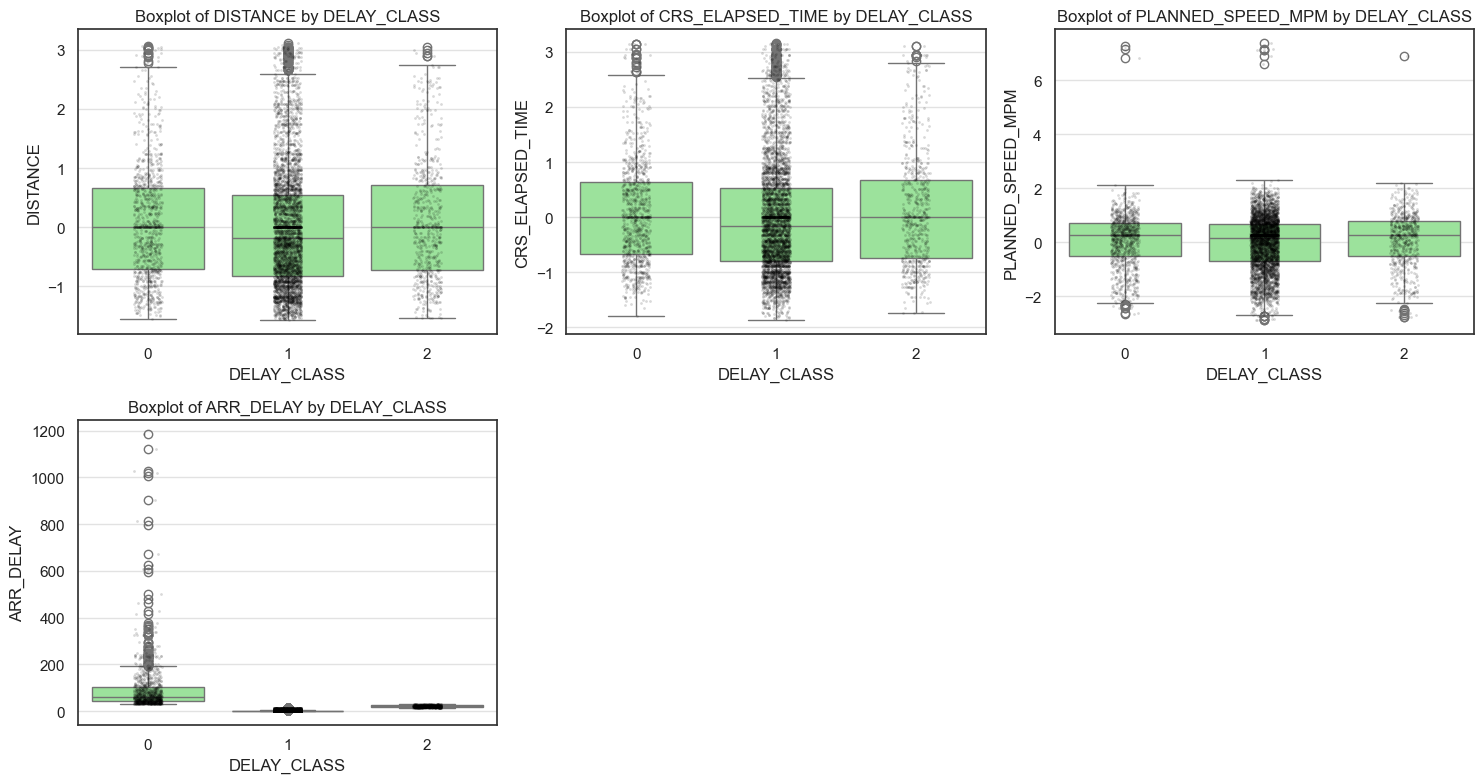

[OK] Grouped boxplots saved: viz_grouped_boxplots_delay_class.png
Generated EDA files:
- eda_boxplots.png
- eda_correlation_matrix.png
- eda_distributions.png
- eda_grouped_boxplots.png
- eda_grouped_distributions.png
- eda_target_distribution.png
- eda_umap_2d.png


In [89]:
# STEP 10: Additional visual diagnostics
viz = DataVisualization(df_features, output_dir=output_dir)
viz.plot_heatmap_top_correlations(top_n=20)

if "DELAY_CLASS" in df_features.columns:
    focus_cols = ["DISTANCE", "CRS_ELAPSED_TIME", "PLANNED_SPEED_MPM", "ARR_DELAY"]
    viz.plot_grouped_feature_distributions(
        columns=focus_cols,
        group_col="DELAY_CLASS",
        filename="viz_grouped_distributions_delay_class.png",
    )
    viz.plot_grouped_boxplots(
        columns=focus_cols,
        group_col="DELAY_CLASS",
        filename="viz_grouped_boxplots_delay_class.png",
    )

generated_eda_files = sorted([p.name for p in output_dir.glob("eda_*.png")])
print("Generated EDA files:")
for name in generated_eda_files:
    print("-", name)


## Phase 3 - Feature Engineering and Transformation

This phase converts cleaned operational fields into model-ready features.

### What is created in this step

- Temporal behavior features
- Route and interaction features
- Delay classification target (`DELAY_CLASS`)
- Encoded categorical columns
- Normalized numeric predictors


In [90]:
# STEP 3: Generate features
engineer = FlightFeatureEngineer(df_clean)
df_features = engineer.generate_features()

# STEP 4: Encode categorical features
df_features = engineer.encode_categorical()

# STEP 5: Normalize numeric features
df_features = engineer.normalize_features()

print("Features shape:", df_features.shape)
print("Total columns:", len(df_features.columns))
print("DELAY_CLASS present:", "DELAY_CLASS" in df_features.columns)
df_features.head(3)


INICIANDO FEATURE ENGINEERING

1. Processando features temporais...
   ✓ 10 features temporais criadas

2. Processando features de rota...
   ✓ 3 features de rota criadas

3. Processando features de categorização...
   ✓ 3 features de categorização criadas

4. Processando features de interação...
   ✓ 3 features de interação criadas

5. Criando variável de classificação (DELAY_CLASS)...
   ✓ Variável DELAY_CLASS criada (3 classes)

FEATURE ENGINEERING CONCLUÍDO!
Total de features novas: 20
Dimensão do dataset: 6424 linhas × 29 colunas

Codificando variáveis categóricas...
   ✓ DISTANCE_CAT codificada
   ✓ DURATION_CAT codificada
   ✓ SPEED_CAT codificada
   ✓ DELAY_CLASS codificada
   ✓ ROUTE codificada

Normalizando features numéricas (StandardScaler)...
   ✓ 23 features normalizadas
Features shape: (6424, 29)
Total columns: 29
DELAY_CLASS present: True


,AIRLINE,AIRLINE_CODE,ORIGIN,DEST,CRS_DEP_TIME,CRS_ARR_TIME,ARR_DELAY,CRS_ELAPSED_TIME,DISTANCE,DELAY_CLASS,...,NIGHT_FLIGHT,ROUTE,ROUTE_FREQUENCY,PLANNED_SPEED_MPM,DISTANCE_CAT,DURATION_CAT,SPEED_CAT,DISTANCE_x_ELAPSED_TIME,DISTANCE_POW2,ELAPSED_TIME_POW2
0,SkyWest Airlines Inc.,OO,DEN,SUN,-0.397887,-0.286820,11.0,-0.164703,-0.385006,1,...,-0.57735,-0.775420,-1.002691,-0.402393,-0.498256,-0.934576,1.156342,-0.426862,-0.491679,-0.302679
1,United Air Lines Inc.,UA,MFE,IAH,-1.285253,-1.291176,0.0,-1.084404,-0.962400,1,...,-0.57735,0.417487,-1.002691,-0.605013,1.224455,1.070004,1.156342,-0.840302,-0.764580,-0.882324
2,Southwest Airlines Co.,WN,ABQ,SAN,-1.470980,-1.494369,0.0,-0.239780,-0.214902,1,...,-0.57735,-1.713040,-1.002691,0.136808,-0.498256,1.070004,-0.850693,-0.369522,-0.382547,-0.360697


In [91]:
# STEP 6: Intermediate checkpoint
loader.data = df_features
checkpoint_clean_path = dataset_path.parent / "checkpoint_cleaned_features.pkl"
loader.save_checkpoint(str(checkpoint_clean_path))

print("Checkpoint created:", checkpoint_clean_path.exists())
print("Checkpoint path:", checkpoint_clean_path)


Checkpoint salvo: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\checkpoint_cleaned_features.pkl
Checkpoint created: True
Checkpoint path: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\checkpoint_cleaned_features.pkl


## Phase 5 - Hypothesis Testing and Final Checkpoint

This final phase provides statistical evidence for feature differences across delay classes.

### Statistical output goals

1. Run a full battery of tests per numeric feature.
2. Export each test family as CSV for reporting and traceability.
3. Save the final checkpoint artifact.


In [92]:
# STEP 11: Hypothesis testing
hypothesis_tester = HypothesisTester(
    data=df_features,
    labels=df_features["DELAY_CLASS"],
    target_col="DELAY_CLASS",
    verbose=False,
)

summary_report = hypothesis_tester.generate_summary_report()


In [93]:
# STEP 12: Export statistical reports
exported_reports = []

for test_name, results_df in summary_report.items():
    if results_df is not None:
        out_csv = output_dir / f"hypothesis_testing_{test_name}.csv"
        results_df.to_csv(out_csv, index=False)
        exported_reports.append(out_csv.name)

print("Exported reports:")
for name in exported_reports:
    print("-", name)


Exported reports:
- hypothesis_testing_normality.csv
- hypothesis_testing_anova.csv
- hypothesis_testing_kruskal_wallis.csv
- hypothesis_testing_levene.csv
- hypothesis_testing_t_tests.csv


In [94]:
# STEP 13: Final checkpoint
loader.data = df_features
checkpoint_final_path = dataset_path.parent / "checkpoint_part1_complete.pkl"
loader.save_checkpoint(str(checkpoint_final_path))

print("Final checkpoint created:", checkpoint_final_path.exists())
print("Final checkpoint path:", checkpoint_final_path)
print("Artifacts directory:", output_dir)


Checkpoint salvo: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\checkpoint_part1_complete.pkl
Final checkpoint created: True
Final checkpoint path: C:\Users\Lenovo\Desktop\DataScience_IA\DataSet\checkpoint_part1_complete.pkl
Artifacts directory: C:\Users\Lenovo\Desktop\DataScience_IA\Output_Files
